In [24]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
# Import data analysis libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [26]:
# Establish connection with database ITEM_DB
connection = sqlite3.connect("/content/drive/MyDrive/TRADE_DB.db")

In [27]:
# Read data from the 'ITEM' table in the database into a pandas dataframe.
df = pd.read_sql_query("SELECT * FROM ITEM", connection)
print(df)

   ItemCode PurchaseDate    ItemName  ItemPrice     Category
0         1   2024-09-27       Pizza        2.0         Food
1         2   2024-09-27       Bread        0.5         Food
2         3   2024-09-28       Apple        1.0         Food
3         4   2024-09-28      Banana        0.5         Food
4         5   2024-09-28       Mango        1.0         Food
5         6   2024-09-29         Pen        1.0   Stationary
6         7   2024-09-29    Notebook        2.0   Stationary
7         8   2024-09-30     Markers        1.0   Stationary
8         9   2024-10-01       Chair        2.0    Furniture
9        10   2024-10-01       Table        3.0    Furniture
10       11   2024-10-02    Keyboard        2.0  Electronics
11       12   2024-10-02       Mouse        2.0  Electronics
12       13   2024-10-03  Calculator        1.0  Electronics
13       14   2024-10-03  USB Memory        1.0  Electronics


In [28]:
# print dataframe without index
print(df.to_string(index=False))

ItemCode PurchaseDate   ItemName  ItemPrice    Category
       1   2024-09-27      Pizza        2.0        Food
       2   2024-09-27      Bread        0.5        Food
       3   2024-09-28      Apple        1.0        Food
       4   2024-09-28     Banana        0.5        Food
       5   2024-09-28      Mango        1.0        Food
       6   2024-09-29        Pen        1.0  Stationary
       7   2024-09-29   Notebook        2.0  Stationary
       8   2024-09-30    Markers        1.0  Stationary
       9   2024-10-01      Chair        2.0   Furniture
      10   2024-10-01      Table        3.0   Furniture
      11   2024-10-02   Keyboard        2.0 Electronics
      12   2024-10-02      Mouse        2.0 Electronics
      13   2024-10-03 Calculator        1.0 Electronics
      14   2024-10-03 USB Memory        1.0 Electronics


In [29]:
# Calculate and print descriptive statistics for ItemPrice column.
countRecords = len(df)
print ("Number of items = %d" % (countRecords))

Number of items = 14


In [30]:
sumPrice = df['ItemPrice'].sum()
print ("Sum of ItemPrice = %.2f" % (sumPrice))

Sum of ItemPrice = 20.00


In [31]:
avgPrice = df['ItemPrice'].mean()
print("Avg. of ItemPrice = %.2f" % (avgPrice))

Avg. of ItemPrice = 1.43


In [32]:
minPrice = df['ItemPrice'].min()
print("Min. of ItemPrice = %.2f" % (minPrice))

Min. of ItemPrice = 0.50


In [33]:
maxPrice = df['ItemPrice'].max()
print("Max. of ItemPrice = %.2f" % (maxPrice))

Max. of ItemPrice = 3.00


In [34]:
sql = """SELECT PurchaseDate, SUM(ItemPrice) AS SumItemPrice FROM ITEM GROUP BY PurchaseDate;"""

In [35]:
itemPriceByDate = pd.read_sql(sql, connection)
print(itemPriceByDate)

  PurchaseDate  SumItemPrice
0   2024-09-27           2.5
1   2024-09-28           2.5
2   2024-09-29           3.0
3   2024-09-30           1.0
4   2024-10-01           5.0
5   2024-10-02           4.0
6   2024-10-03           2.0


Text(0, 0.5, 'Sum of Item Price')

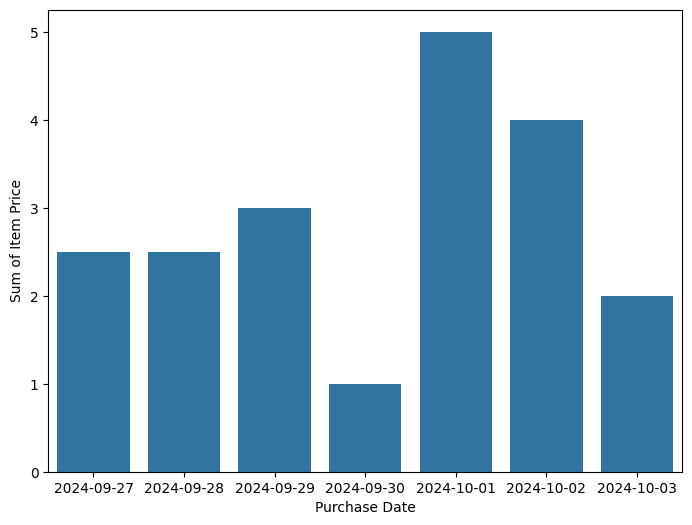

In [36]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
ax = sns.barplot(x='PurchaseDate', y='SumItemPrice', data=itemPriceByDate)
plt.xlabel("Purchase Date")
plt.ylabel("Sum of Item Price")

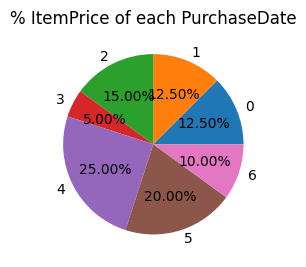

In [37]:
plt.subplot(1, 2, 2)
plt.pie(itemPriceByDate['SumItemPrice'], labels=itemPriceByDate.index, autopct='%1.2f%%')
plt.title("% ItemPrice of each PurchaseDate")
plt.show(block=False)

In [38]:
connection.close()